# 03 - Swing Output Value (SOV) Construction

## MLB Ballpark Effects on Pitch Type Frequency & Contact Quality

This notebook constructs the **Swing Output Value (SOV)** metric — a continuous [-1, 1] 
scale measuring the quality of contact on every ball in play, independent of park environment.

SOV is built from two Statcast inputs: exit velocity (EV) and launch angle (LA). Rather than 
approximating xwOBA — which requires actual batted ball outcomes unavailable in this dataset — 
SOV is constructed as a direct contact quality composite, designed from first principles to 
reward the EV and LA combinations that produce elite contact in Major League Baseball.

SOV will be the analytical core of this project. All park-level comparisons in notebooks 4 through 
7 are built on top of what is produced here.

___
## 1) Data Load & Elite Contact Zone Definition

In [26]:
# Data Load

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DB_PATH = Path(r"C:\Users\Bryce Gelarden\OneDrive - Indiana University\Documents\Github - brycemgelarden\MLB_Ballpark_Factor_Analysis\database\mlb_ballpark_effects.db")
conn = sqlite3.connect(DB_PATH)

in_play = pd.read_sql_query("""
    SELECT * FROM swings
    WHERE swing_outcome = 'in_play'
    AND launch_speed IS NOT NULL
    AND launch_angle IS NOT NULL
""", conn)

print(f"SOV-eligible observations loaded: {len(in_play):,}")

SOV-eligible observations loaded: 63,625


### Elite Contact — Definition & Target

In Major League Baseball, **elite contact** is defined by the simultaneous combination of 
*how hard* and *at what angle* a ball is struck. Neither dimension alone is sufficient:

- A ball hit at **105 mph into the ground** (-10°) is wasted power
- A ball hit at **28° off the end of the bat** (65 mph) will die in the infield

SOV is built around a single elite contact target — the EV/LA coordinate that represents 
the peak of batted ball quality:

| Parameter | Value | Rationale |
|---|---|---|
| `EV_TARGET` | **105 mph** | Well into Statcast barrel territory |
| `LA_TARGET` | **28°** | Center of the home run producing sweet spot |
| `EV_SCALE` | Sample EV stdev. | Normalizes EV to equal footing with LA in distance calculation |
| `LA_SCALE` | Sample LA stdev. | Normalizes LA to equal footing with EV in distance calculation |

Every observation in the SOV-eligible sample (n=63,625) receives a score based on its 
**two-dimensional proximity** to this target. Balls struck close to 105 mph / 28° score 
near **1.0**. Balls far from that target in either dimension — weak contact, steep grounders, 
popups — score near **0.0**.

*The scale factors (respective standard deviations) ensure EV and LA contribute equally to the proximity score, 
preventing either variable from dominating simply due to its wider raw unit range.*

In [32]:
EV_TARGET = 105.0
LA_TARGET  = 28.0


print(f"Elite contact target:  {EV_TARGET} mph  /  {LA_TARGET}°")
print(f"\nSample EV stdev:         {in_play['launch_speed'].std():.2f} mph")
print(f"Sample LA stdev:         {in_play['launch_angle'].std():.2f}°")

Elite contact target:  105.0 mph  /  28.0°

Sample EV stdev:         14.93 mph
Sample LA stdev:         28.75°


In [33]:
# Reassign scale factors to actual sample standard deviations
# Ensures EV and LA contribute equally to the proximity score
EV_SCALE = round(in_play["launch_speed"].std(), 2)
LA_SCALE = round(in_play["launch_angle"].std(), 2)

print(f"EV scale factor (std): {EV_SCALE}")
print(f"LA scale factor (std): {LA_SCALE}")

EV scale factor (std): 14.93
LA scale factor (std): 28.75


___
## 2) Joint EV/LA Proximity Scoring + Surface Visualization

Score every observation by 2D Guassian proximity to that definied 'elite contact target'.  Both EV and LA must be favorable simultaneously to score near 1.0.  Observations far from target (in either dimension) are penalized continously.

In [ ]:
def joint_contact_score(ev, la):
    ev_component = ((ev - EV_TARGET) / EV_SCALE) ** 2
    la_component = ((la - LA_TARGET) / LA_SCALE) ** 2
    return np.exp(-0.5 * (ev_component + la_component))

in_play["raw_score"] = in_play.apply(
    lambda row: joint_contact_score(row["launch_speed"], row["launch_angle"]), axis=1
)

print(f"raw_score range: {in_play['raw_score'].min():.4f} – {in_play['raw_score'].max():.4f}")
print(f"\nraw_score percentiles:")
print(in_play["raw_score"].quantile([0.05, 0.25, 0.50, 0.75, 0.95]).round(4))

raw_score range: 0.0000 – 1.0000

raw_score percentiles:
0.05    0.0019
0.25    0.1177
0.50    0.4017
0.75    0.7215
0.95    0.9516
Name: raw_score, dtype: float64


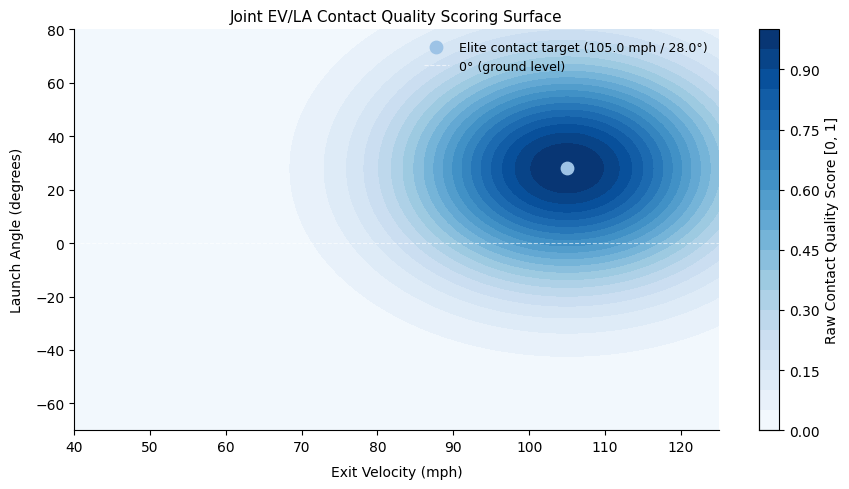

In [35]:
# Visualize

ev_range = np.linspace(40, 125, 300)
la_range = np.linspace(-70, 80, 300)
EV_GRID, LA_GRID = np.meshgrid(ev_range, la_range)
SCORE_GRID = np.exp(-0.5 * (((EV_GRID - EV_TARGET) / EV_SCALE) ** 2 +
                             ((LA_GRID - LA_TARGET) / LA_SCALE) ** 2))

fig, ax = plt.subplots(figsize=(9, 5))

contour = ax.contourf(EV_GRID, LA_GRID, SCORE_GRID, levels=20, cmap="Blues")
plt.colorbar(contour, ax=ax, label="Raw Contact Quality Score [0, 1]")

ax.scatter(EV_TARGET, LA_TARGET, color="#9DC3E6", s=80, zorder=5,
           label=f"Elite contact target ({EV_TARGET} mph / {LA_TARGET}°)")
ax.axhline(0, color="white", linewidth=0.8, linestyle="--", alpha=0.6, label="0° (ground level)")

ax.set_xlabel("Exit Velocity (mph)", labelpad=8)
ax.set_ylabel("Launch Angle (degrees)", labelpad=8)
ax.set_title("Joint EV/LA Contact Quality Scoring Surface", fontsize=11)
ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()

*Quick Note*: The ellipse is wider horizontally (measuring EV), and narrower vertically (measuring LA), indicating the surface is more senstive to launch angle changes than exit velocity changes.  In other words, a small move up or down in launch angle shrinks the score faster than an equivalent move left or right in exit velocity.
<br><br>
This makes 'baseball' sense - 5 degree change in launch angle can be the difference in a barrel and a pop-up, while 5 mph change in EV at elite contact is nowhere near as catastrophic.

___
## 3) Percentile Ranking

Empirical percentile rank of `raw_score` across all 63,625 SOV-eligible observations.  We make no assumptions to the distribution, rank is purely based within the sample.  `scipy.stats.rankdata` handles a tied value by averaging.

In [36]:
from scipy.stats import rankdata

in_play["percentile"] = rankdata(in_play["raw_score"]) / len(in_play)

print(f"percentile range: {in_play['percentile'].min():.4f} – {in_play['percentile'].max():.4f}")
print(f"\npercentile distribution:")
print(in_play["percentile"].quantile([0.05, 0.25, 0.50, 0.75, 0.95]).round(4))

percentile range: 0.0000 – 1.0000

percentile distribution:
0.05    0.05
0.25    0.25
0.50    0.50
0.75    0.75
0.95    0.95
Name: percentile, dtype: float64


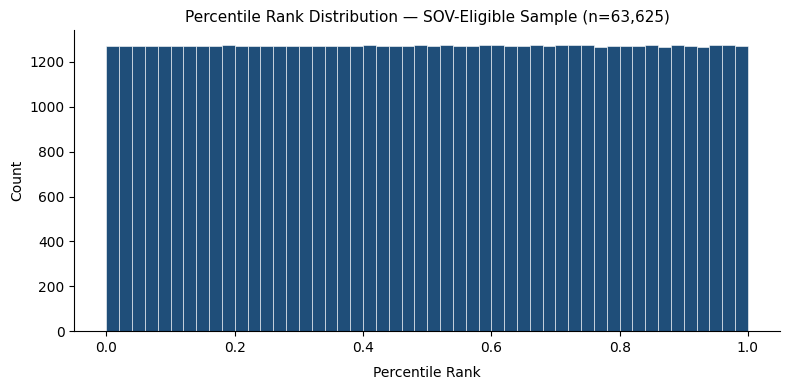

In [ ]:
# Confirmation the percentile distribution is uniform
  # This is NOT an assumption of distribution as mentioned previously, just ensuring the ranking worked correctly

fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(in_play["percentile"], bins=50, color="#1F4E79", edgecolor="white", linewidth=0.4)

ax.set_xlabel("Percentile Rank", labelpad=8)
ax.set_ylabel("Count")
ax.set_title(f"Percentile Rank Distribution — SOV-Eligible Sample (n={len(in_play):,})", fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

___
## 4) Linear Mapping to [-1.0 , +1.0]

___
## 5) Validation & Distribution Check

___
## 6) Write Back to SQLite (Database)